# Retail Sales Analysis Using Python

## Project Objective

The goal of this project is to perform end-to-end retail sales analysis using Python. The project includes data cleaning, feature engineering, exploratory data analysis, and data visualization to answer key business questions such as:

- Which products generate the highest revenue?
- Which stores perform the best?
- Who are the most valuable customers?
- How do sales vary by day, month, quarter, and year?
- What sales patterns can help improve business decisions?

The insights generated from this analysis can help businesses optimize inventory management, improve marketing strategies, and enhance overall sales performance.

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Business Insights & Recommendations
8. Conclusion

# Import Libraries

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns",None)


# Load DataSet

In [3]:
df = pd.read_excel(r"C:\Users\jatin\Downloads\QVI_transaction_data.xlsx")

In [4]:
customer = pd.read_csv(r"C:\Users\jatin\Downloads\QVI_purchase_behaviour.csv")

In [5]:
df = pd.merge(
    df,
    customer,
    on='LYLTY_CARD_NBR',
    how='left'
)

In [6]:
df['LIFESTAGE'].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48596
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [7]:
df['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    101988
Budget         93157
Premium        69691
Name: count, dtype: int64

# Data Exploration

In [8]:
df.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,MIDAGE SINGLES/COUPLES,Budget
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,MIDAGE SINGLES/COUPLES,Budget
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,MIDAGE SINGLES/COUPLES,Budget
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,MIDAGE SINGLES/COUPLES,Budget


In [9]:
df.tail()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium
264835,43365,272,272380,270189,74,Tostitos Splash Of Lime 175g,2,8.8,YOUNG SINGLES/COUPLES,Premium


In [10]:
df.sample(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
28475,43502,32,32191,29184,111,Smiths Chip Thinly Cut Original 175g,2,6.0,NEW FAMILIES,Mainstream
210263,43439,128,128041,130745,20,Doritos Cheese Supreme 330g,2,11.4,YOUNG FAMILIES,Mainstream
66479,43450,209,209049,207780,113,Twisties Chicken270g,2,9.2,OLDER FAMILIES,Mainstream
133866,43349,248,248288,250569,99,Pringles Sthrn FriedChicken 134g,1,3.7,OLDER SINGLES/COUPLES,Premium
177616,43443,112,112078,114195,26,Pringles Sweet&Spcy BBQ 134g,2,7.4,RETIREES,Premium


In [11]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [12]:
df.dtypes

DATE                  int64
STORE_NBR             int64
LYLTY_CARD_NBR        int64
TXN_ID                int64
PROD_NBR              int64
PROD_NAME            object
PROD_QTY              int64
TOT_SALES           float64
LIFESTAGE            object
PREMIUM_CUSTOMER     object
dtype: object

In [13]:
df.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'LIFESTAGE', 'PREMIUM_CUSTOMER'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264836 non-null  int64  
 1   STORE_NBR         264836 non-null  int64  
 2   LYLTY_CARD_NBR    264836 non-null  int64  
 3   TXN_ID            264836 non-null  int64  
 4   PROD_NBR          264836 non-null  int64  
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


In [15]:
df.shape

(264836, 10)

#  Data Cleaning

In [16]:
df.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [29]:
(df.isnull().sum()/len(df))*100

DATE                0.0
STORE_NBR           0.0
LYLTY_CARD_NBR      0.0
TXN_ID              0.0
PROD_NBR            0.0
PROD_NAME           0.0
PROD_QTY            0.0
TOT_SALES           0.0
LIFESTAGE           0.0
PREMIUM_CUSTOMER    0.0
dtype: float64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df = df.drop_duplicates()

In [44]:
df['DATE'] = df['DATE'].dt.normalize()


In [46]:
df.columns=df.columns.str.strip()

# Feature Engineering

In [47]:
df['Year']=df['DATE'].dt.year
df['Month']=df['DATE'].dt.month_name()
df['Quarter']=df['DATE'].dt.quarter
df['Day']=df['DATE'].dt.day_name()
df['Month Number']=df['DATE'].dt.month
df['Price_Per_Product'] = df['TOT_SALES'] /df['PROD_QTY']

# Exploratory Data Analysis (EDA)

In [48]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])
print("Stores :",df['STORE_NBR'].nunique())
print("Customers :",df['LYLTY_CARD_NBR'].nunique())
print("Products :",df['PROD_NAME'].nunique())
print("Transaction :",df['TXN_ID'].nunique())

Rows : 264835
Columns : 16
Stores : 272
Customers : 72637
Products : 114
Transaction : 263127


In [49]:
print(df['TOT_SALES'].sum())

1934409.0


In [50]:
print(df['PROD_QTY'].sum())

505122


In [51]:
print(df['TOT_SALES'].mean())

7.304204504691601


# Business Insights & Recommendations

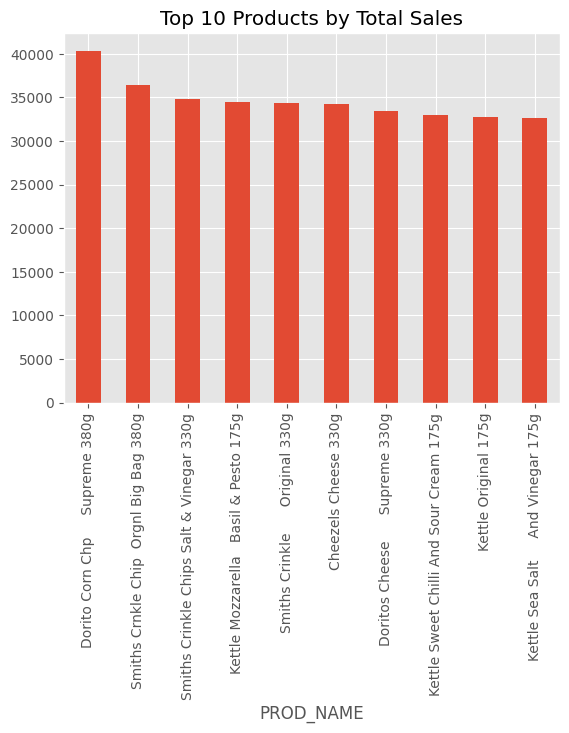

In [52]:
top_Products = (
    df.groupby('PROD_NAME')['TOT_SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_Products.plot(kind='bar')
plt.title('Top 10 Products by Total Sales')
plt.show()

## Insights
Dorito corn Chp  generates the highest total sales making it the best-performing product the top 10 contribute the major share of revenue
## Recommendation
 Maintain sufficient stock of these products and promote lower-selling products throught bundle offers

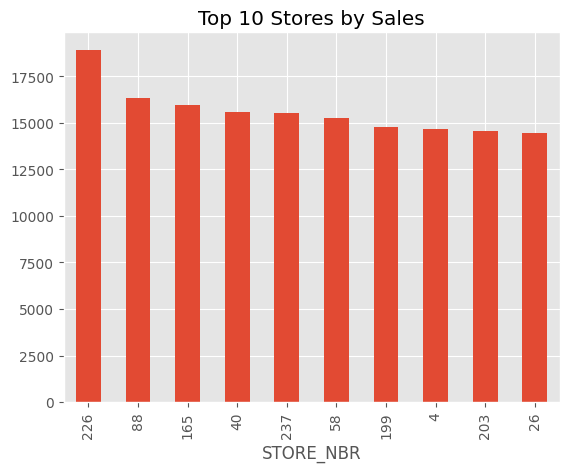

In [53]:
top_store = df.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending=False).head(10)
top_store.plot(kind='bar')
plt.title("Top 10 Stores by Sales")
plt.show()

# Insights
Store 266  recorded the highest sales among all stores Sales vary significantly across stores indicating differences in customer demand
# Recommendation
Analyze the strategies of the top-performing store and apply them to lower performing stores.

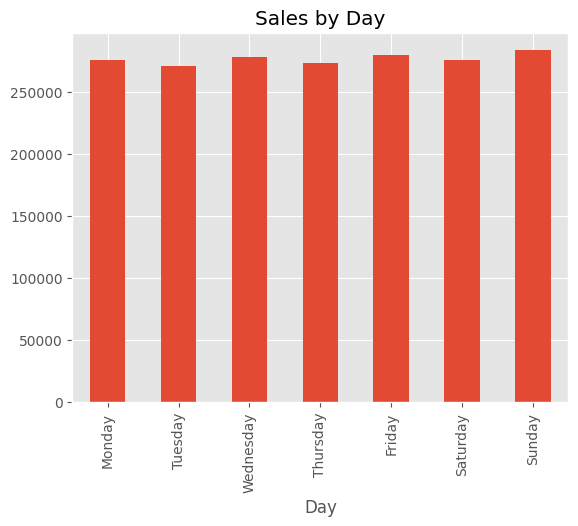

In [54]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
day_sales = df.groupby('Day')['TOT_SALES'].sum().reindex(order)
day_sales.plot(kind='bar')
plt.title('Sales by Day')
plt.show()

# Insights 
Sunday generated the highest sales indicating stronger customer activity on that day Sales are lower on Tuesday showing weaker demand
# Recommendation
Allocate more staff and inventory on peak days and run special offers on slower days

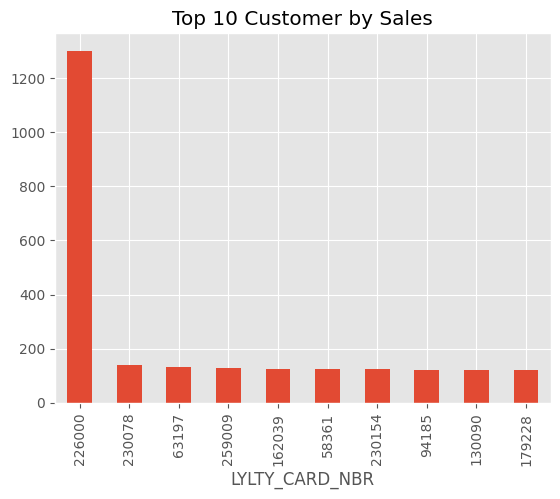

In [55]:
customer_sales = (
    df.groupby('LYLTY_CARD_NBR')['TOT_SALES']
        .sum()
        .sort_values(ascending=False)
        .head(10)
)
customer_sales.plot(kind='bar')
plt.title("Top 10 Customer by Sales")
plt.show()

# Insights 
Customer 226000 spent the most and is the highest-value customer A small number of customers contribute a large portion of total sales.
# Recommendation
Reward loyal customers with exclusive offers and loyalty programs

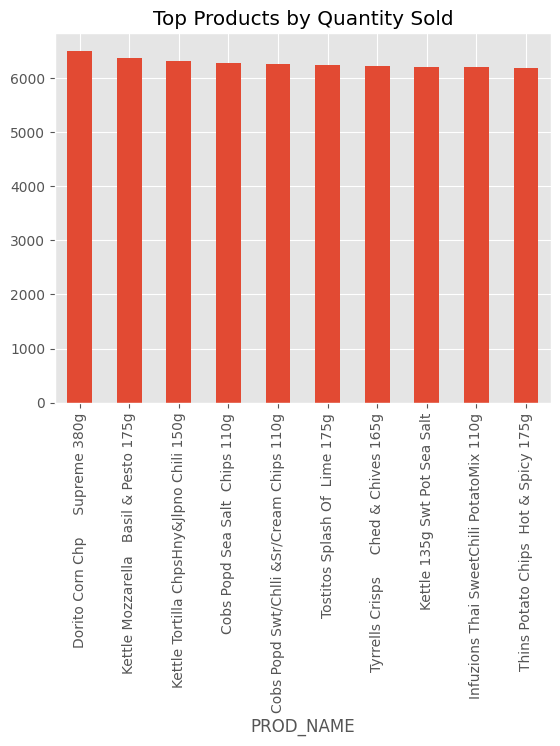

In [56]:
quantity = df.groupby('PROD_NAME')['PROD_QTY'].sum().sort_values(ascending=False).head(10)
quantity.plot(kind='bar')
plt.title('Top Products by Quantity Sold')
plt.show()

# Insights
Dorito corn Chp sold the highest quantity making it the most frequently purchased product High sales volume reflects strong customer demand.
# Recommendation
Ensure adequate stock and feature these products in promotional campaigns

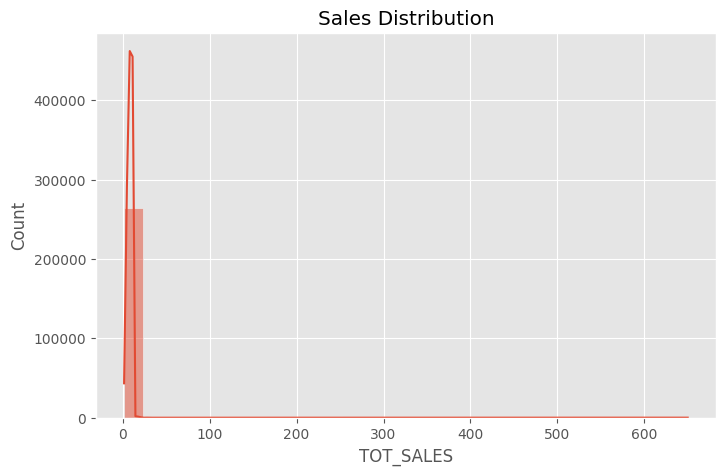

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(df['TOT_SALES'],bins=30,kde=True)
plt.title("Sales Distribution")
plt.show()

## Insights 
Ensure adequate stock and feature these products in promotional campaigns
## Recommendation
Increase average order value through combo offers or cross-selling strategies

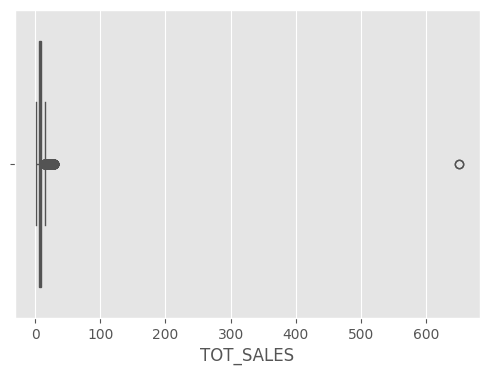

In [58]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["TOT_SALES"])

plt.show()

## Insights
The boxplot identifies several high-value sales outliers These may represent bulk purchases or premium customer orders
## Recommendation
Analyze these transactions to identify opportunities for business customers or premium sales

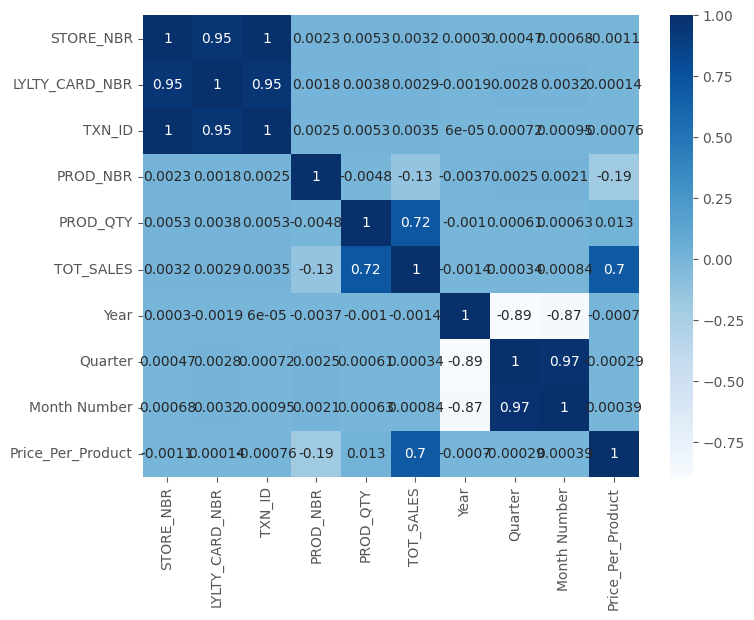

In [59]:
numeric = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric.corr(),annot=True,cmap='Blues')
plt.show()

## Insights
PROD_QTY and TOT_SALES show a positive relationship, indicating that higher quantities generally result in higher sales
other numerical variables have relatively weaker relationships
## Recommendation
Focus on increasing the quantity purchased per transaction through upselling and bundle offers

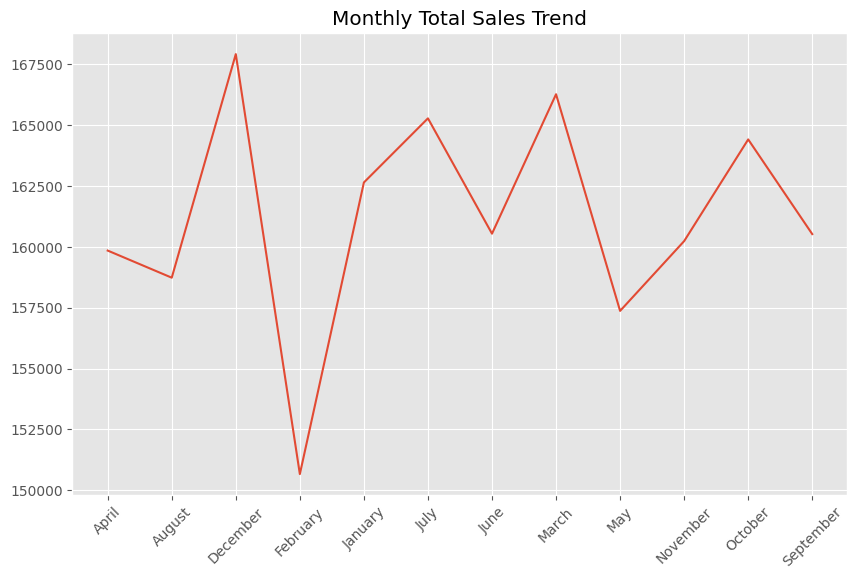

In [60]:
monthly_sales = df.groupby('Month')['TOT_SALES'].sum()
plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index,monthly_sales.values)
plt.title('Monthly Total Sales Trend')
plt.xticks(rotation=45)
plt.show()

## Insights 
December recorded the highest sales, while February had the lowest sales. Monthly sales show seasonal variations in customer demand.
## Recommendation
Increase inventory and marketing efforts before peak months, and introduce promotional offers during low-sales months.

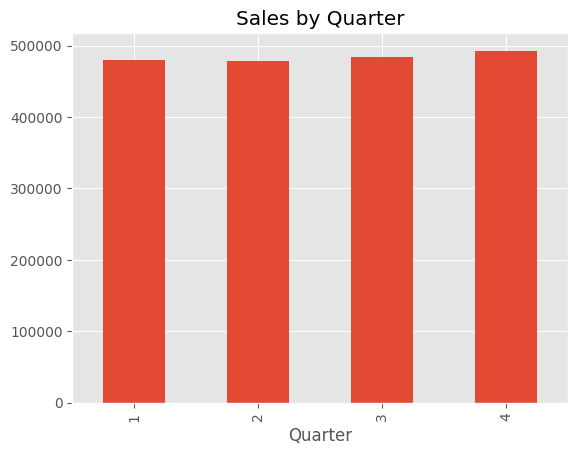

In [61]:
quarter = df.groupby('Quarter')['TOT_SALES'].sum()
quarter.plot(kind='bar')
plt.title("Sales by Quarter")
plt.show()

## Insights
Quarter 4 (Q4) generated the highest revenue, whereas Quarter 1 (Q1) recorded the lowest.
Q4 appears to be the strongest sales period of the year.
## Recommendation
Plan major marketing campaigns and maintain sufficient inventory before Q4 to maximize sales.

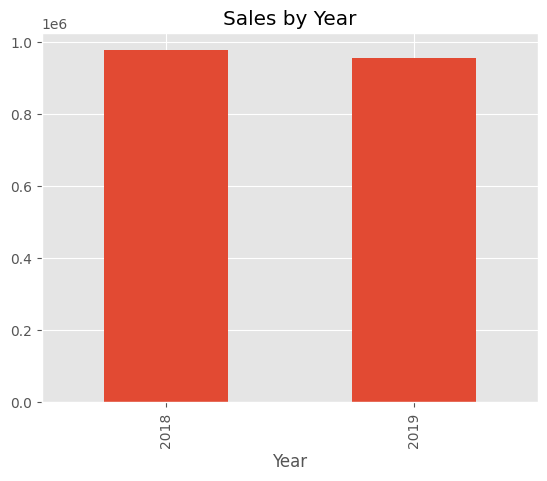

In [62]:
yearly = df.groupby('Year')['TOT_SALES'].sum()
yearly.plot(kind='bar')
plt.title('Sales by Year')
plt.show()

## Insights 
2018 achieved the highest total sales, indicating the strongest business performance during the analyzed period.
The yearly trend helps evaluate overall business growth over time.
## recommendation
Analyze the factors that contributed to the strong performance in 2018 and apply similar strategies in future years.

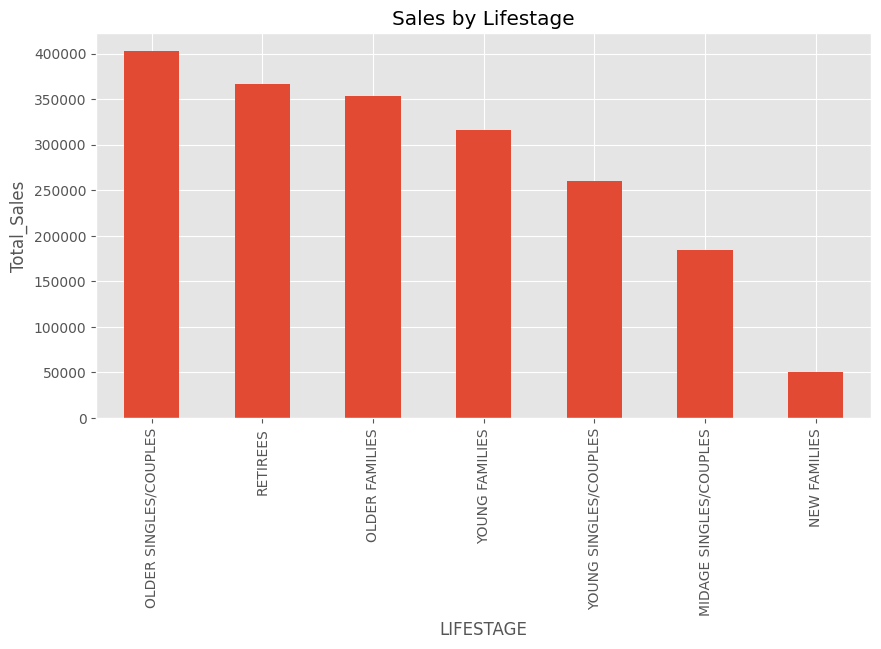

In [63]:
sales_life = (
    df.groupby('LIFESTAGE')['TOT_SALES']
    .sum()
    .sort_values(ascending=False)
)
sales_life

plt.figure(figsize=(10,5))
sales_life.plot(kind='bar')
plt.title("Sales by Lifestage")
plt.ylabel("Total_Sales")
plt.show()

## Insights
Older single couple generates the highest revenue 
## Recommendation
Target this customer segment with personalised promotion

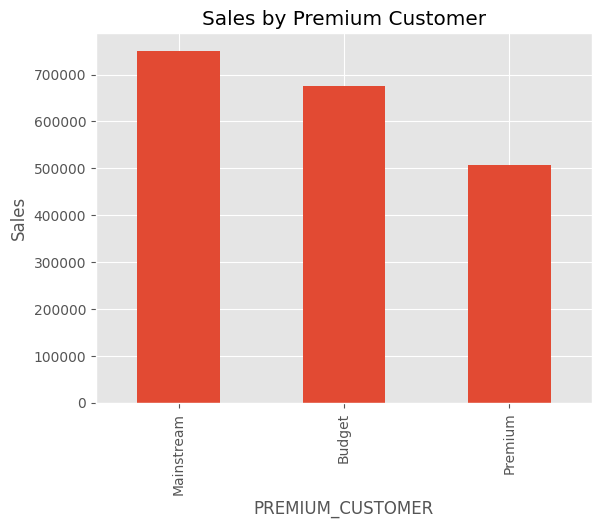

In [64]:
sales_pre = (
    df.groupby('PREMIUM_CUSTOMER')['TOT_SALES']
    .sum()
    .sort_values(ascending=False)
)
sales_pre

sales_pre.plot(kind='bar')
plt.title("Sales by Premium Customer")
plt.ylabel("Sales")
plt.show()

## Insights 
Mainstream customer generates the highest revenue across the customer indicates this customer has high potential of buyer 
## Recommendation
Run ads do campainghn for buying products in bundle offer 

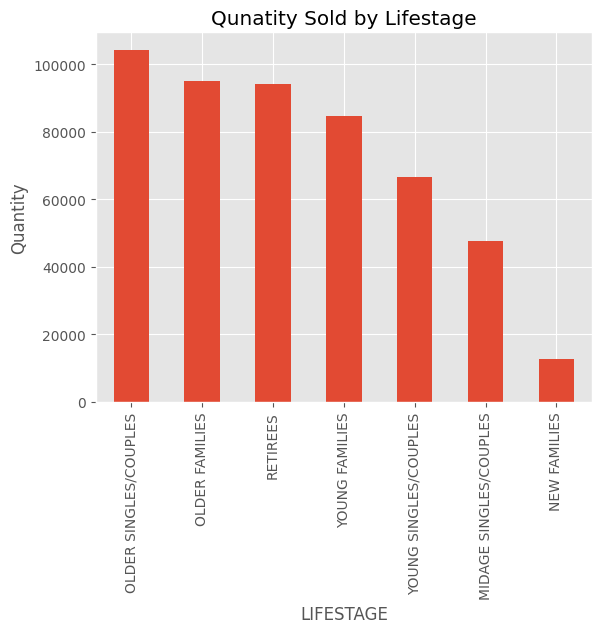

In [65]:
qty = (
    df.groupby('LIFESTAGE')['PROD_QTY']
    .sum()
    .sort_values(ascending=False)
)
qty.plot(kind='bar')
plt.title("Qunatity Sold by Lifestage")
plt.ylabel("Quantity")
plt.show()

## Insights 
Older single couples buyes the high quantity then everyone else indicates this is our potential buyer 
## Recommendation
Give personalised offers give discount promote ads 

In [66]:
avg = (
    df.groupby('LYLTY_CARD_NBR')['TOT_SALES']
        .sum()
    .mean()
)
print(avg)

26.631179701804864


In [67]:
avg_txn = (
    df.groupby('TXN_ID')['TOT_SALES']
    .sum()
    .mean()
)
print(avg_txn)

7.351617279868656


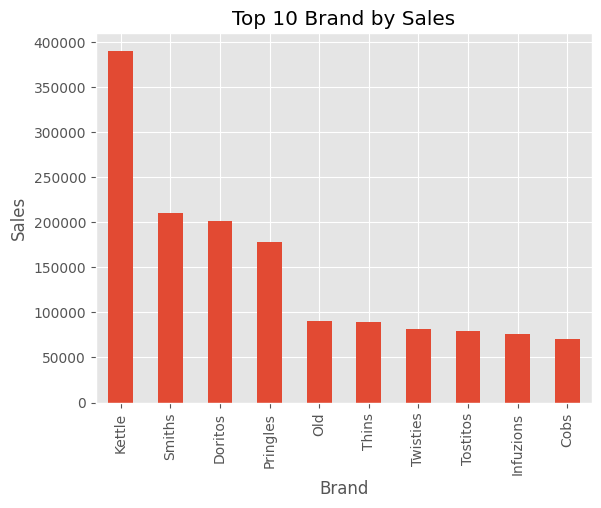

In [68]:
df['Brand']=df['PROD_NAME'].str.split().str[0]

brand = (
    df.groupby('Brand')['TOT_SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
brand.plot(kind='bar')
plt.title('Top 10 Brand by Sales')
plt.ylabel('Sales')
plt.show()

## Insights 
Kettle brand generates the highest revenue across the products indicates the the strong brand that generates reveneu 
## Recommendation
Increase inventory for all top that highes revenue run ads do some personalised marketing

In [69]:
df['Pack_Size']=df['PROD_NAME'].str.extract(r'(\d+)').astype(int)

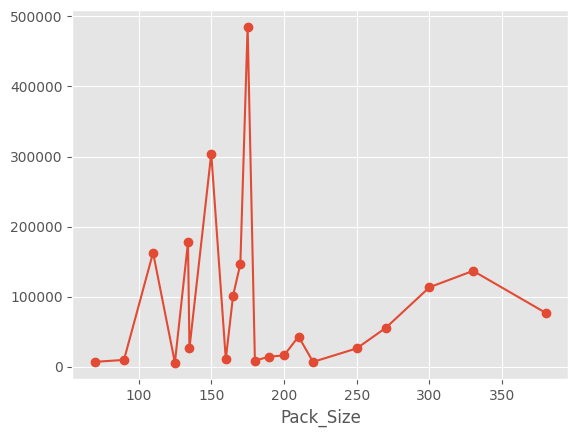

In [70]:
pack = (
    df.groupby('Pack_Size')['TOT_SALES']
    .sum()
)
pack.plot(marker='o')
plt.show()

## Insight
While the 170g pack leads in revenue, total unit sales volume must be verified to confirm absolute consumer preference
## Recommendation
Validate volume and margin data before increasing inventory or launching targeted promotional campaigns.

In [71]:
segment = (
    df.groupby(
        ['LIFESTAGE','PREMIUM_CUSTOMER']
    )
    .agg(
        Total_Sales=('TOT_SALES','sum'),
        Total_Qty = ('PROD_QTY','sum'),
        Customer=('LYLTY_CARD_NBR','nunique')
    )
)
segment

Total_Sales  Total_Qty  Customer
LIFESTAGE              PREMIUM_CUSTOMER                                  
MIDAGE SINGLES/COUPLES Budget               35514.80       9496      1504
                       Mainstream           90803.85      22699      3340
                       Premium              58432.65      15526      2431
NEW FAMILIES           Budget               21928.45       5571      1112
                       Mainstream           17013.90       4319       849
                       Premium              11491.10       2957       588
OLDER FAMILIES         Budget              168363.25      45065      4675
                       Mainstream          103445.55      27756      2831
                       Premium              81958.40      22171      2274
OLDER SINGLES/COUPLES  Budget              136769.80      35220      4929
                       Mainstream          133393.80      34997      4930
                       Premium             132257.15      33984      4750
RETIREES               Budget              113147.80      28764      4454
                       Mainstream          155677.05      40518      6479
                       Premium              97646.05      24884      3872
YOUNG FAMILIES         Budget              139345.85      37111      4017
                       Mainstream           92788.75      25044      2728
                       Premium              84025.50      22406      2433
YOUNG SINGLES/COUPLES  Budget               61141.60      16671      3779
                       Mainstream          157621.60      38632      8088
                       Premium              41642.10      11331      2574

## Conclusion

### Key Insights
- **Older Singles/Couples** generated the highest total sales and purchased the highest quantity of chips.
- **Mainstream** customers were the largest purchasing customer segment.
- **Kettle** was the highest-selling chip brand.
- **170g** was the most popular pack size, generating the highest sales.

### Recommendations
- Focus marketing campaigns and loyalty offers on **Older Singles/Couples**, as they are the most valuable customer segment.
- Ensure adequate inventory of **Kettle** chips, especially **170g** packs, to meet customer demand.
- Design targeted promotions for **Mainstream** customers to increase repeat purchases and strengthen customer retention.

## Project Objective

Analyze customer purchasing behaviour and chip sales data to identify high-value customer segments, popular brands, preferred pack sizes, and key purchasing trends. Generate data-driven business insights and strategic recommendations to support category management decisions.